In [1]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, recall_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

Caricamento e visualizzazione dei canali

In [3]:
data = sio.loadmat('../data/signal__b.mat')
g0 = data['g__0']   # negativi
g1 = data['g__1']   # positivi

# --- Plot dei 32 canali per la riga 20 di g__0 ---

# unit = 509
# plt.figure()

# for channels in range(32):
#     plt.clf()
#     plt.plot(g0[19, channels * unit : (channels + 1) * unit])
#     plt.ylim([-30, 30])
#     plt.title('Channel ' + str(channels*unit +1) + '-' + str((channels+1)*unit))
#     plt.pause(0.5)

Random Forest, Stratified K-fold, K=5

In [4]:
data0 = g0.astype(np.float64)
data1 = g1.astype(np.float64)

# --- Calcolo delle dimensioni (quante righe/campioni ci sono) ---

N0 = data0.shape[0]
N1 = data1.shape[0]

data = np.vstack([data0, data1])                # (N0+N1, 32*509)
labels = np.hstack((np.zeros(N0), np.ones(N1))) # np.hstack affianca un array di 0 e un array di 1

# --- Creiamo un array che va da 0 fino a (N0+N1 - 1) ---

original_indices = np.arange(N0 + N1)
NNeg = N0
NPos = N1

# --- Parametri di training ---

K = 5

rf_model = RandomForestClassifier()

skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=1)

acc_results = []  # array che ritorna accuracy per ogni fold
sens_results = [] # sensitivity
spec_results = [] # specificity

# --- Ciclo K-fold ---
print('--------------------')

fold_number = 1

for train_index, test_index in skf.split(data,labels):
    data_train, data_test = data[train_index], data[test_index]
    labels_train, labels_test = labels[train_index], labels[test_index]
    
    # fase di training
    rf_model.fit(data_train, labels_train)
    
    # fase di testing
    predictions = rf_model.predict(data_test)
    
    # confronta le previsioni con le soluzioni vere
    accuracy = accuracy_score(labels_test, predictions)
    sensitivity = recall_score(labels_test, predictions, pos_label=1)
    specificity = recall_score(labels_test, predictions, pos_label=0)
    
    acc_results.append(accuracy)
    sens_results.append(sensitivity)
    spec_results.append(specificity)
    
    # stampiamo i risultati
    print(f"Fold {fold_number}:     "
          f"Accuracy = {accuracy * 100:.2f}%     "
          f"Sensitivity = {sensitivity * 100:.2f}%     "
          f"Specificity = {specificity * 100:.2f}%     ")
    
    fold_number +=1
    
print('--------------------')
print("Media sui K fold:")
print('--------------------')
print(f"Accuracy media = {np.mean(acc_results)*100:.2f}%")
print(f"Sensitivity media = {np.mean(sens_results)*100:.2f}%")
print(f"Specificity media = {np.mean(spec_results)*100:.2f}%")
print('--------------------')
acc_results_all_channels = np.mean(acc_results)

--------------------
Fold 1:     Accuracy = 55.56%     Sensitivity = 75.00%     Specificity = 40.00%     
Fold 2:     Accuracy = 55.56%     Sensitivity = 50.00%     Specificity = 60.00%     
Fold 3:     Accuracy = 88.89%     Sensitivity = 100.00%     Specificity = 75.00%     
Fold 4:     Accuracy = 66.67%     Sensitivity = 40.00%     Specificity = 100.00%     
Fold 5:     Accuracy = 87.50%     Sensitivity = 100.00%     Specificity = 75.00%     
--------------------
Media sui K fold:
--------------------
Accuracy media = 70.83%
Sensitivity media = 73.00%
Specificity media = 70.00%
--------------------


Osserviamo l'andamento della performance in funzione di K numero di fold.

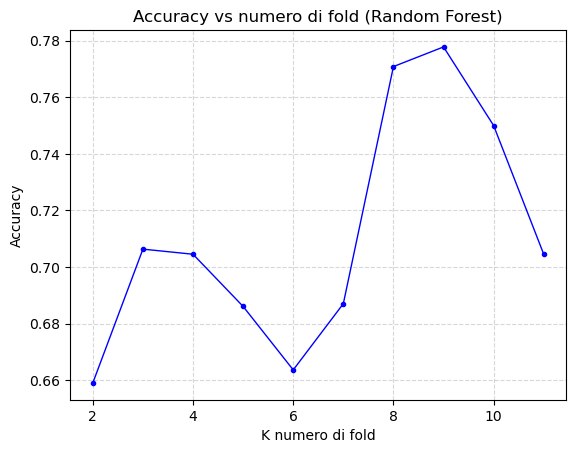

In [6]:
NUMK = 11

acc_numk = [] # array di accuracy in funzione di numvar

for numk in range(2, NUMK +1):
    
    skf = StratifiedKFold(n_splits=numk, shuffle=True, random_state=1)
    rf_model = RandomForestClassifier()
    
    acc_folds = []  # array di accuracy per un singolo fold
    
    for train_index, test_index in skf.split(data,labels):
        data_train, data_test = data[train_index], data[test_index]
        labels_train, labels_test = labels[train_index], labels[test_index]
        
        # fase di training
        rf_model.fit(data_train, labels_train)
        
        # fase di testing
        predictions = rf_model.predict(data_test)
        
        # confronta le previsioni con le soluzioni vere
        accuracy = accuracy_score(labels_test, predictions)
        
        # accuracy per questo fold
        acc_folds.append(accuracy)
        
    acc_numk.append(np.mean(acc_folds))

# --- Plot accuracy vs K numero di fold ---

plt.figure()
plt.plot(np.arange(2, NUMK+1), acc_numk, marker='o', color='b', linewidth=1, markersize=3)
plt.xlabel('K numero di fold')
plt.ylabel('Accuracy')
plt.title('Accuracy vs numero di fold (Random Forest)')
plt.grid(True, linestyle='--', alpha = 0.5)
plt.show()

Determiniamo l'andamento dell'accuratezza in funzione del numero di variabili utilizzate.

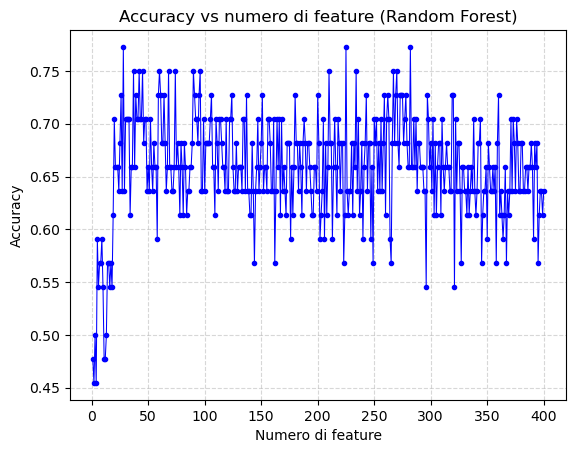

In [10]:
NUMVAR = 400

acc_numvar = [] # array di accuracy in funzione di numvar

for numvar in range(1, NUMVAR +1):
    
    rf_model = RandomForestClassifier(n_estimators=100)
    
    acc_folds = []  # array di accuracy per un singolo fold
    
    for train_index, test_index in skf.split(data,labels):
        data_train, data_test = data[train_index, :numvar], data[test_index, :numvar]
        labels_train, labels_test = labels[train_index], labels[test_index]
        
        # fase di training
        rf_model.fit(data_train, labels_train)
        
        # fase di testing
        predictions = rf_model.predict(data_test)
        
        # confronta le previsioni con le soluzioni vere
        accuracy = accuracy_score(labels_test, predictions)
        
        # accuracy per questo fold
        acc_folds.append(accuracy)
        
    acc_numvar.append(np.mean(acc_folds))

# --- Plot accuracy vs numero di features ---

plt.figure()
plt.plot(np.arange(1, NUMVAR+1), acc_numvar, marker='o', color = 'b', markersize=3, linewidth=0.75)
plt.xlabel('Numero di feature')
plt.ylabel('Accuracy')
plt.title('Accuracy vs numero di feature (Random Forest)')
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.show()

Questo ci dice che è sufficiente considerare <50 variabili: andando oltre il valore dell'accuratezza è oscillante intonrno a un valor medio stabile.

Ora effettuiamo PCA per ridurre la dimensionalità dei dati, e osserviamo l'andamento dell'accuratezza in funzione della dimensionalità dei dati.

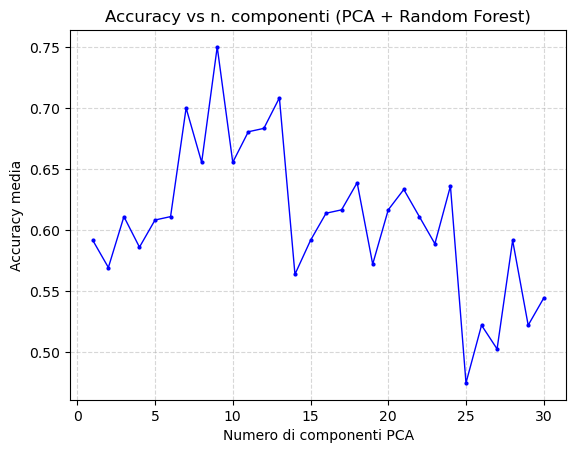

--------------------
MAX Accuracy:    75.00
MAX Sensitivity: 78.00
MAX Specificity: 73.00
Numero di componenti: 9
--------------------


In [12]:
K = 5
NUMDIM = 30

skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=1)

acc_numdim = []   # array di accuracy in funzione di numvar = dimensione ridotta dei campioni tramite PCA
sens_numdim = []
spec_numdim = []

# --- Ciclo for su numvar = dimensione ridotta tramite PCA ---

for numdim in range(1, NUMDIM + 1):

    acc_folds = []   # array di accuracy per singolo fold
    sens_folds = []
    spec_folds = []

    for train_index, test_index in skf.split(data, labels):
        data_train, data_test = data[train_index], data[test_index]
        labels_train, labels_test = labels[train_index], labels[test_index]

        # PCA sul TRAIN (riduce a numvar componenti)
        pca = PCA(n_components = numdim)
        data_train_pca = pca.fit_transform(data_train)
        data_test_pca  = pca.transform(data_test) 

        # SVM lineare
        rf_model = RandomForestClassifier()
        
        # training
        rf_model.fit(data_train_pca, labels_train)
        
        # testing 
        predictions = rf_model.predict(data_test_pca)
        
        # metriche per questo fold
        acc  = accuracy_score(labels_test, predictions)
        sens = recall_score(labels_test, predictions, pos_label=1)
        spec = recall_score(labels_test, predictions, pos_label=0)

        acc_folds.append(acc)
        sens_folds.append(sens)
        spec_folds.append(spec)
    
    # medie sui K fold per questo numvar
    acc_numdim.append(np.mean(acc_folds))
    sens_numdim.append(np.mean(sens_folds))
    spec_numdim.append(np.mean(spec_folds))
    

plt.figure()
plt.plot(np.arange(1, NUMDIM + 1), acc_numdim, marker='o', color='b', linewidth=1, markersize=2)
plt.xlabel('Numero di componenti PCA')
plt.ylabel('Accuracy media')
plt.title('Accuracy vs n. componenti (PCA + Random Forest)')
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.show()

# --- Risultati migliori ---
best_idx = int(np.argmax(acc_numdim))
best_numdim = best_idx + 1

print('--------------------')
print(f'MAX Accuracy:    {acc_numdim[best_idx]*100:.2f}')
print(f'MAX Sensitivity: {sens_numdim[best_idx]*100:.2f}')
print(f'MAX Specificity: {spec_numdim[best_idx]*100:.2f}')
print(f'Numero di componenti: {best_numdim}')
print('--------------------')

Varianza spiegata da ogni componente:

In [13]:
pca_best = PCA(n_components=best_numdim)
data_pca = pca_best.fit_transform(data)

print('--------------------')
print(f'Numero ottimale di componenti: {best_numdim}')
print('--------------------')

# --- Varianza spiegata da ogni componente ---
print('Varianza spiegata da ogni componente')
print('--------------------')
print(pca_best.explained_variance_ratio_)
print('--------------------')

# --- Varianza cumulativa ---
print('Varianza cumulativa')
print('--------------------')

cumulative_variance = np.cumsum(pca_best.explained_variance_ratio_)
print(cumulative_variance)
print('--------------------')                       # primo autovettore (lunghezza 32*509)

--------------------
Numero ottimale di componenti: 9
--------------------
Varianza spiegata da ogni componente
--------------------
[0.20213323 0.09628827 0.08192238 0.07689901 0.05368407 0.04969158
 0.0444608  0.03818386 0.03566012]
--------------------
Varianza cumulativa
--------------------
[0.20213323 0.2984215  0.38034388 0.4572429  0.51092696 0.56061855
 0.60507935 0.64326321 0.67892333]
--------------------


Plottiamo la prima componente principale e individuiamo i 5 canali più importanti.

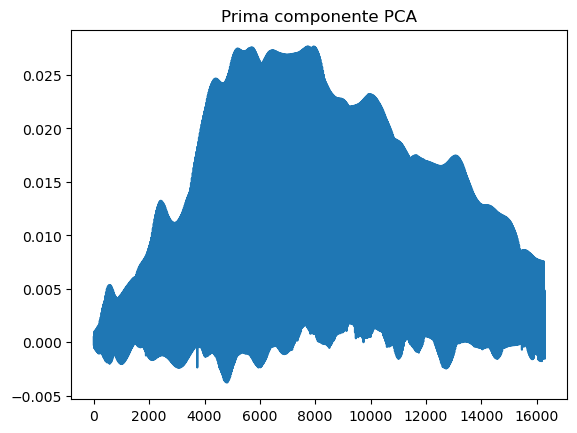

--------------------
Canali dei 5 coefficienti più grandi della prima componente principale: [7735 7960 7703 7928 7767 7671 7992 7799 7896]
--------------------
Valori dei coefficienti: [0.02765618 0.02764863 0.02764786 0.02764183 0.02763939 0.02761279
 0.02761076 0.02760326 0.02759239]
--------------------


In [14]:
# --- Autovettori (componenti principali) ---
U = pca_best.components_  # (best_numvar, n_feature_originali)


v1 = U[0]  # primo autovettore

plt.plot(v1)
plt.title('Prima componente PCA')
plt.show()

# --- 

v1_ordered = np.argsort(v1)
indexes_max = v1_ordered[-9:][::-1]
print('--------------------')
print(f'Canali dei 5 coefficienti più grandi della prima componente principale: {indexes_max}')
print('--------------------')
print(f'Valori dei coefficienti: {v1[indexes_max]}')
print('--------------------')

Zoom nell'intorno dei canali corrispondenti ai coefficienti massimi della prima componente.

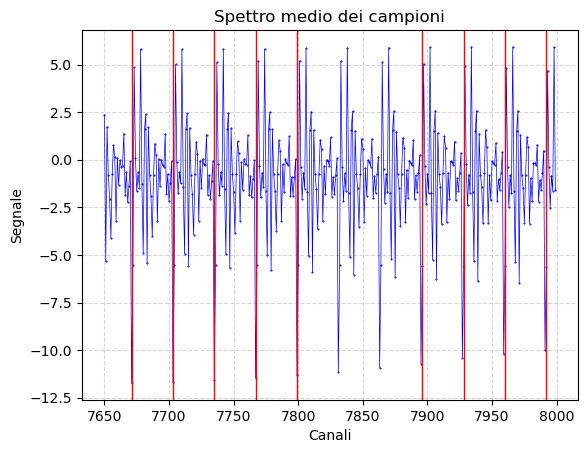

In [15]:
# --- Calcoliamo lo spettro medio del segnale B ---

spectrum_sum = data.sum(axis=0)
spectrum_mean = data.sum(axis=0) / (N0+N1)

# --- Plottiamo nell'intorno dei canali corrispondenti ai massimi ---
x = np.arange(7650,8000)
plt.figure()
plt.plot(x, spectrum_mean[x], marker='o', markersize=0.5, color='b', linewidth=0.5)

for index in indexes_max:
    plt.axvline(x=index, color='r', linewidth=1)
plt.xlabel('Canali')
plt.ylabel('Segnale')
plt.title('Spettro medio dei campioni')
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.show()

Calcolare accuratezza usando solo i canali nella regione dei massimi di v1: [4500,8500] e confrontare con accuratezza ottenuta usando tutti i canali

In [16]:
data = np.vstack([data0, data1])                # (N0+N1, 32*509)
labels = np.hstack((np.zeros(N0), np.ones(N1))) # np.hstack affianca un array di 0 e un array di 1

data_important_channels = data[:, 4500 : 8500]

# --- Parametri di training ---

K = 5
#rf_model 

rf_model = RandomForestClassifier()

skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=1)

acc_results = []  # array che ritorna accuracy per ogni fold

# --- Ciclo K-fold ---
print('--------------------')

fold_number = 1

for train_index, test_index in skf.split(data_important_channels,labels):
    data_train, data_test = data_important_channels[train_index], data_important_channels[test_index]
    labels_train, labels_test = labels[train_index], labels[test_index]
    
    # fase di training
    rf_model.fit(data_train, labels_train)
    
    # fase di testing
    predictions = rf_model.predict(data_test)
    
    # confronta le previsioni con le soluzioni vere
    accuracy = accuracy_score(labels_test, predictions)
  
    
    acc_results.append(accuracy)

    
    # stampiamo i risultati
    print(f"Fold {fold_number}:     "
          f"Accuracy = {accuracy * 100:.2f}%     ")
    
    fold_number +=1
    
print('--------------------')
print("Media sui K fold:")
print('--------------------')
print(f"Accuracy media con i canali importanti = {np.mean(acc_results)*100:.2f}%")
print('--------------------')
print(f"Accuracy media con tutti i canali = {acc_results_all_channels*100:.2f}%")
print('--------------------')

--------------------
Fold 1:     Accuracy = 66.67%     
Fold 2:     Accuracy = 66.67%     
Fold 3:     Accuracy = 77.78%     
Fold 4:     Accuracy = 77.78%     
Fold 5:     Accuracy = 62.50%     
--------------------
Media sui K fold:
--------------------
Accuracy media con i canali importanti = 70.28%
--------------------
Accuracy media con tutti i canali = 70.83%
--------------------


Ora testing sul segnale A: effetuiamo PCA sul segnale A per ridurre il dataset del segnale A per avere la stessa dimensione del segnale B.

--------------------
Numero ottimale di componenti: 9
--------------------
Varianza spiegata da ogni componente
--------------------
[0.25667327 0.10414138 0.08990018 0.0665092  0.04828367 0.04442628
 0.04096181 0.03247374 0.02990354]
--------------------
Varianza cumulativa
--------------------
[0.25667327 0.36081465 0.45071483 0.51722403 0.56550769 0.60993398
 0.65089579 0.68336953 0.71327306]
--------------------


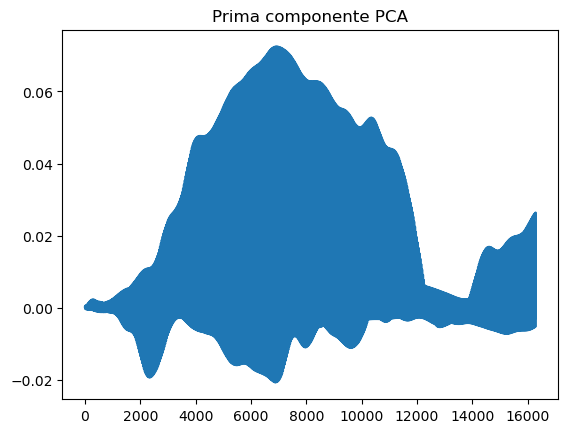

In [19]:
data_a = sio.loadmat('../data/signal__a.mat')
g0_a = data_a['g__0']   # negativi
g1_a = data_a['g__1']   # positivi


data0_a = g0_a.astype(np.float64)
data1_a = g1_a.astype(np.float64)


# --- Calcolo delle dimensioni (quante righe/campioni ci sono) ---
N0_a = data0_a.shape[0]
N1_a = data1_a.shape[0]

data_a = np.vstack([data0_a, data1_a])                # (N0+N1, 32*509)
labels_a = np.hstack((np.zeros(N0_a), np.ones(N1_a))) # np.hstack affianca un array di 0 e un array di 1

# -- PCA sul segnale A
pca_a = PCA(n_components = best_numdim)
data_test_pca_a  = pca_a.fit_transform(data_a) 


# --- Autovettori (componenti principali) ---
U = pca_a.components_

print('--------------------')
print(f'Numero ottimale di componenti: {best_numdim}')
print('--------------------')

# --- Varianza spiegata da ogni componente ---
print('Varianza spiegata da ogni componente')
print('--------------------')
print(pca_a.explained_variance_ratio_)
print('--------------------')

# --- Varianza cumulativa ---
print('Varianza cumulativa')
print('--------------------')

cumulative_variance = np.cumsum(pca_a.explained_variance_ratio_)
print(cumulative_variance)
print('--------------------')

v1 = U[0]                          # primo autovettore (lunghezza 32*509)

plt.plot(v1)
plt.title('Prima componente PCA')
plt.show() 

Facciamo un training e testing sulla pca di b e facciamo testing sulle componenti principali e sul modello a

In [26]:
# alleniamo il modello sulle componenti principali di B
acc_folds = []  
sens_folds = []
spec_folds = []

for train_index, test_index in skf.split(data, labels):
    data_train, data_test = data[train_index], data[test_index]
    labels_train, labels_test = labels[train_index], labels[test_index]

     # PCA sul TRAIN (riduce a numdim componenti)
    pca = PCA(n_components = best_numdim)
    data_train_pca = pca.fit_transform(data_train)
    data_test_pca  = pca.transform(data_test) 

    # SVM lineare
    rf_model = RandomForestClassifier()
        
    # training
    rf_model.fit(data_train_pca, labels_train)
        
     # testing 
    predictions = rf_model.predict(data_test_pca)
        
     # metriche per questo fold
    acc  = accuracy_score(labels_test, predictions)
    sens = recall_score(labels_test, predictions, pos_label=1)
    spec = recall_score(labels_test, predictions, pos_label=0)

    acc_folds.append(acc)
    sens_folds.append(sens)
    spec_folds.append(spec)
    
    # medie sui K fold per questo numdim
    acc_numdim.append(np.mean(acc_folds))
    sens_numdim.append(np.mean(sens_folds))
    spec_numdim.append(np.mean(spec_folds))
    

N0_a = g0_a.shape[0]
N1_a = g1_a.shape[0]
y_a = np.hstack((np.zeros(N0_a), np.ones(N1_a)))

# Testiamo il modello sul segnale A
data_a_test = data_test_pca_a 
previsioni = rf_model.predict(data_a_test)
accuratezza = accuracy_score(y_a, previsioni)

# --- STAMPIAMO LA PAGELLA ---
print('--------------------')
print("RISULTATI DEL TEST")
print('--------------------')
print(f"Campioni esaminati: {data_a_test.shape[0]}")
print('--------------------')
print(f"Dimensioni usate: {data_a_test.shape[1]}")
print('--------------------')
print(f"Accuratezza finale: {accuratezza * 100:.2f}%")
print('--------------------')

--------------------
RISULTATI DEL TEST
--------------------
Campioni esaminati: 44
--------------------
Dimensioni usate: 9
--------------------
Accuratezza finale: 54.55%
--------------------
